# Task Overview

> Objective(s):
1. **Identifying Top Products:** Determine the top-selling products based on total transaction revenue per day.  
2. **Detecting Anomalies:** Identify unusual transaction patterns, such as a sharp increase or decrease in sales for a specific product.  
3. **Finding Most Profitable Locations:** Determine which city or province generates the highest total transaction revenue.  

> This work will be done in the following phase(s):

> 1: Initial Analysis Using ChatGPT

> a. **Generate Insights with ChatGPT**  
> - Use ChatGPT as an assistant to help solve the case study.  
> - Ask relevant questions to ChatGPT, such as how to structure the analysis, preprocess the data, or detect anomalies.  
> - Document each prompt given to ChatGPT and its corresponding response.  

> b. **Evaluate ChatGPT’s Responses**
> - Analyze the results generated by ChatGPT.  
> - Identify strengths and weaknesses in its approach.  
> - Note any limitations or inaccuracies in the suggested methodology.  

> 2: Improving the Solution

> a. **Refine the Analysis**  
> - Improve upon ChatGPT’s solution by addressing gaps in its methodology.  
> - Enhance data processing, statistical accuracy, anomaly detection, and visualization.  
> - Implement better handling of edge cases or missing data.  

> b. **Provide Justifications for Improvements**  
> - Clearly explain why each modification is necessary.  
> - Demonstrate how the improvements lead to a more reliable and actionable analysis.  

# Dataset Overview

> I used ChatGPT to help solve the given case study tasks. I asked relevant questions about how to structure the analysis, preprocess the provided dataset, and detect anomalies. All prompts and its corresponding response were documented and accessible by this link: https://chatgpt.com/share/680fe11c-cac0-8012-aba0-0014eb9e8707

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_path = "../Soal 1 - Data Transformation dan Analysis Case/ecommerce-session-bigquery.csv"
df = pd.read_csv(dataset_path)
df.head()

,fullVisitorId,channelGrouping,time,country,city,totalTransactionRevenue,transactions,timeOnSite,pageviews,sessionQualityDim,...,itemQuantity,itemRevenue,transactionRevenue,transactionId,pageTitle,searchKeyword,pagePathLevel1,eCommerceAction_type,eCommerceAction_step,eCommerceAction_option
0,2515546493837534633,Organic Search,966564,Taiwan,(not set),NaN,NaN,1567.0,82.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,/storeitem.html,0,1,NaN
1,9361741997835388618,Organic Search,157377,France,not available in demo dataset,NaN,NaN,321.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,/storeitem.html,0,1,NaN
2,7313828956068851679,Referral,228279,United States,San Francisco,NaN,NaN,927.0,11.0,63.0,...,NaN,NaN,NaN,NaN,NaN,NaN,/storeitem.html,0,1,NaN
3,6036794406403793540,Organic Search,1615618,United States,Boulder,NaN,NaN,1616.0,13.0,38.0,...,NaN,NaN,NaN,NaN,NaN,NaN,/storeitem.html,0,1,NaN
4,7847280609739507227,Organic Search,37832,Canada,not available in demo dataset,NaN,NaN,1222.0,45.0,53.0,...,NaN,NaN,NaN,NaN,NaN,NaN,/storeitem.html,0,1,NaN


> The dataset used for this analysis, as it is written at the instructions of this case study, is a subset of the **'data-to-insights.ecommerce.all_sessions'** dataset from Google BigQuery. It includes information such as:  
- **Visitor ID** (unique identifier for visitors)  
- **Visit Time** (timestamp of the visit)  
- **Product SKU & Product Name** (product identifiers and descriptions)  
- **Transaction Count** (number of transactions for each product)  
- **City & Province** (geographical data related to transactions)  

In [3]:
df.shape

(10000, 32)

> This dataset has 100000 rows with 32 columns each.

# Identifying Top Products

> From the chatbot's response, it became clear that the important fields are date, productSKU, v2ProductName, and productRevenue. Based on the few rows I provided, it quickly identified that a significant number of productRevenue values are null. As a solution, it suggested `dropping rows` where productRevenue is null. For now, I need to first examine the dataset to assess how many null values are present.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fullVisitorId            10000 non-null  uint64 
 1   channelGrouping          10000 non-null  object 
 2   time                     10000 non-null  int64  
 3   country                  10000 non-null  object 
 4   city                     10000 non-null  object 
 5   totalTransactionRevenue  619 non-null    float64
 6   transactions             628 non-null    float64
 7   timeOnSite               9713 non-null   float64
 8   pageviews                9999 non-null   float64
 9   sessionQualityDim        19 non-null     float64
 10  date                     10000 non-null  int64  
 11  visitId                  10000 non-null  int64  
 12  type                     10000 non-null  object 
 13  productRefundAmount      0 non-null      float64
 14  productQuantity        

> Based on the provided information, the product revenue is entirely null. The chatbot suggested an alternative, which was to use transaction revenue, however, that also returned null values. I recommended `changing the approach`, but the chatbot then suggested to assume that the product quantity for all items was 1. Ultimately, rather than randomly assuming and changing the product quantity without any valid reason, I advised using the total transaction revenue instead.

> The solution to this issue is somewhat risky, as filtering or dropping null values may not accurately reflect the true data, especially if the filtered results are limited. `In my opinion, there are several better approaches to address the missing values`, perhaps using methods such as mean, median, or imputation. I suggested this approach and pointed out that there are alternative methods to simply dropping values. However, I tried to asked the chatbot if there was any specific reason for opting to drop the values. It turned out that the chatbot was a bit inconsistent, but eventually, the chatbot mentioned `'tracking valid transactions,'` which seemed reasonable and relevant to the task. This led me to reconsider, as `imputation methods are generally better suited for predictive tasks rather than for showing results`. Ultimately, I decided to stick with the original plan and proceed by dropping the null values.

> Another positive thing is that the chatbot remembered that the 'date' column wasn't in datetime format. However, as the plan was being revised, it seemed to forget this detail as well, which is `a common issue with bots`, they tend to overlook important aspects.

> The next issue was that the chatbot used `plt.line`, which wasn’t a good choice for a dataset that was already reduced (by date). When I pointed this out, it simply displayed the table's top 10 rows instead. So, I suggested switching to a barplot.

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

In [6]:
topSellingProduct = df.dropna(subset=['totalTransactionRevenue'])
topSellingProduct = topSellingProduct.groupby('v2ProductName')['totalTransactionRevenue'].sum().reset_index()

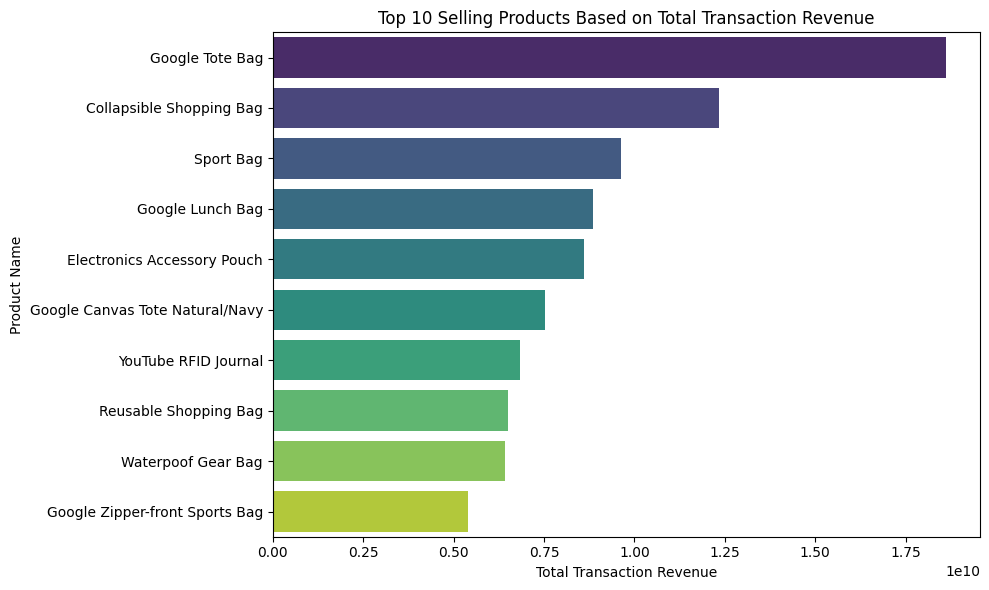

In [7]:
topSellingProduct = topSellingProduct.sort_values(by='totalTransactionRevenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=topSellingProduct.head(10), x='totalTransactionRevenue', y='v2ProductName', palette='viridis', hue='v2ProductName', legend=False)
plt.title('Top 10 Selling Products Based on Total Transaction Revenue')
plt.xlabel('Total Transaction Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

> From this graph, it's clear that the Google Tote Bag is the most popular by a large margin, followed by the Collapsible Shopping Bag, which has a noticeable gap compared to the third most popular item. After that, the remaining items have relatively similar numbers. Therefore, the focus should be on the top two. The reasons behind their strong sales could be a combination of factors, such as the product's functionality, the brand’s influence in building consumer trust, or other elements.

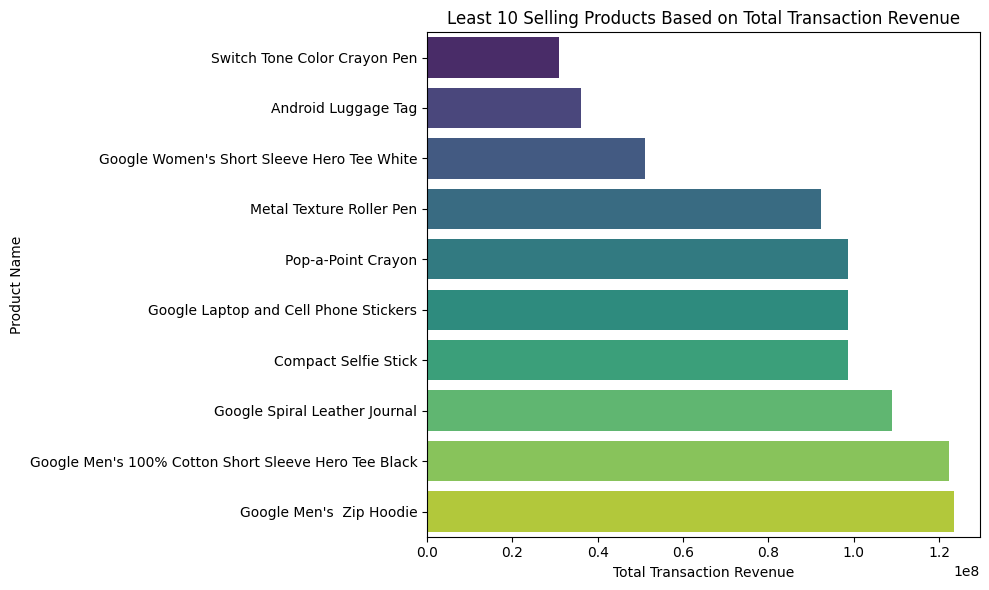

In [ ]:
leastSellingProduct = topSellingProduct.sort_values(by='totalTransactionRevenue', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=leastSellingProduct.head(10), x='totalTransactionRevenue',y='v2ProductName', palette='viridis', hue='v2ProductName', legend=False)
plt.title('Least 10 Selling Products Based on Total Transaction Revenue')
plt.xlabel('Total Transaction Revenue')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

> As for the least-selling products, the three items with similar sales figures should also be closely evaluated. There are several factors to consider, such as high pricing with poor quality, lack of item awareness, or other potential reasons that could be impacting their sales.

> By understanding the reasons behind why certain products are selling so well while others aren't, business strategies can be adapted and refined accordingly.

# Detecting Anomalies

> This time, the bot proceeded with using PCT and presented the graph. However, I felt it was difficult to fully assess the accuracy of its judgment solely based on that. After some consideration, I requested to revert it to its previous idea of using PCT, but this time, to present the data in a table format instead.

> Percentage Change (PCT) is indeed a great tool for detecting data anomalies like sharp increases or decreases. Calculating the percentage change between consecutive values in a dataset can easily spot any sudden shifts in trends. A significant PCT change indicates that something unusual has occurred, such as a sharp spike or drop, which may point to an anomaly. This is especially useful for time-series data, where tracking trends over time is crucial.

In [ ]:
anomalies = df.dropna(subset=['totalTransactionRevenue'])
anomalies = anomalies[['date', 'v2ProductName', 'totalTransactionRevenue']]
anomalies['pct_change'] = anomalies.groupby('v2ProductName')['totalTransactionRevenue'].pct_change() * 100

anomalies = anomalies.sort_values(by='pct_change', ascending=False)
anomalies

,date,v2ProductName,totalTransactionRevenue,pct_change
2191,2016-10-02,Google Pet Feeding Mat,2.447870e+09,13067.670791
1163,2016-09-15,1 oz Hand Sanitizer,1.894180e+09,11414.772036
1580,2016-09-15,Suitcase Organizer Cubes,1.894180e+09,7798.999166
9576,2016-08-25,Sport Bag,6.239580e+09,7031.763630
6412,2016-09-08,Google Canvas Tote Natural/Navy,4.006100e+08,6842.980936
...,...,...,...,...
7295,2016-08-02,Chevron Shopper,2.733000e+07,NaN
8143,2016-09-25,Google Zipper-front Sports Bag,5.846000e+07,NaN
8590,2016-08-30,Waterproof Gear Bag,4.111500e+08,NaN
8596,2016-08-22,Waterpoof Gear Bag,1.503400e+08,NaN


: 

> Since the top 5 items were clearly visible, with the top three showing a PCT change of 7798% or higher, I decided to go ahead and create the graph.

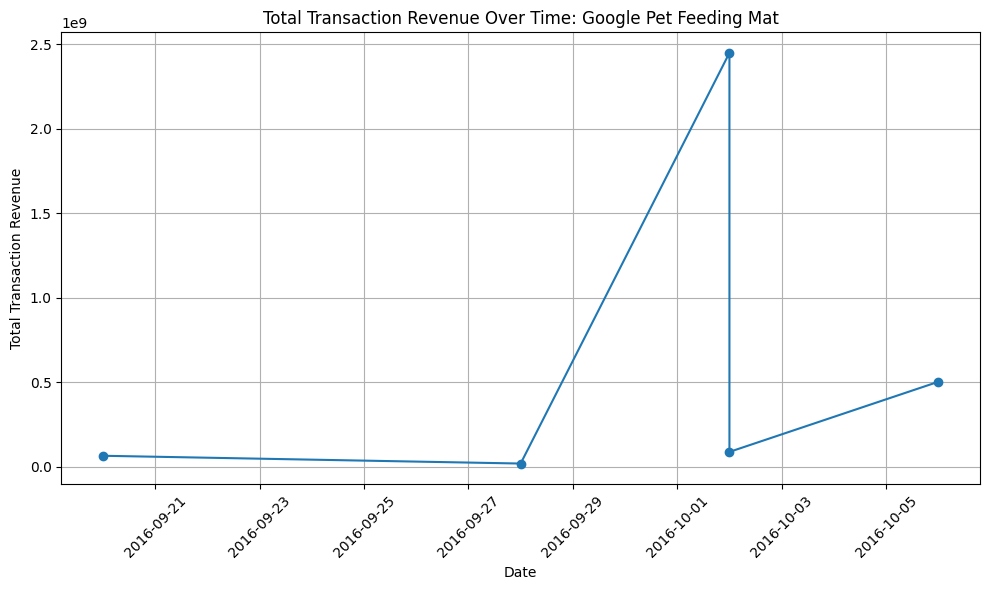

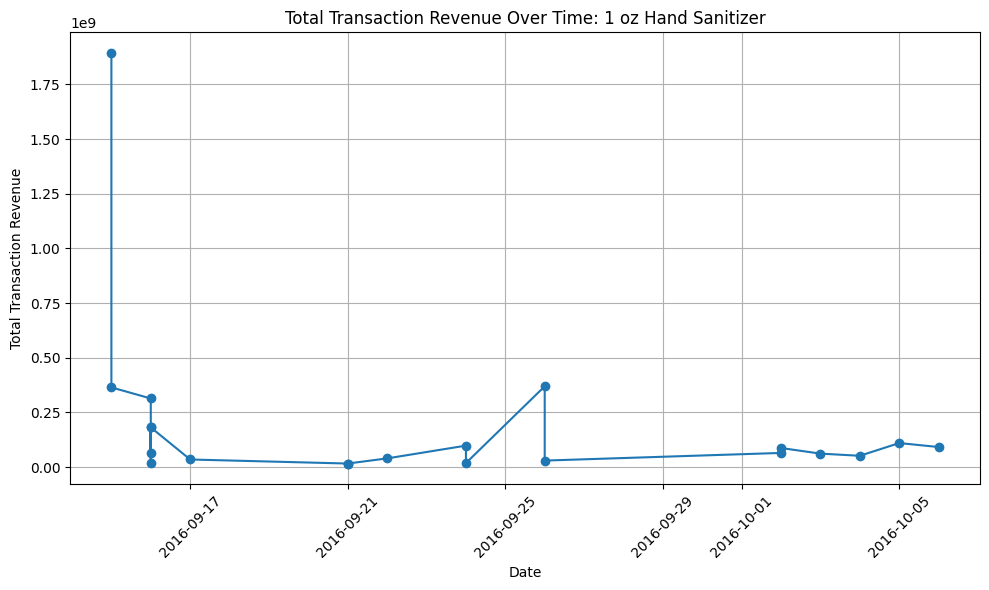

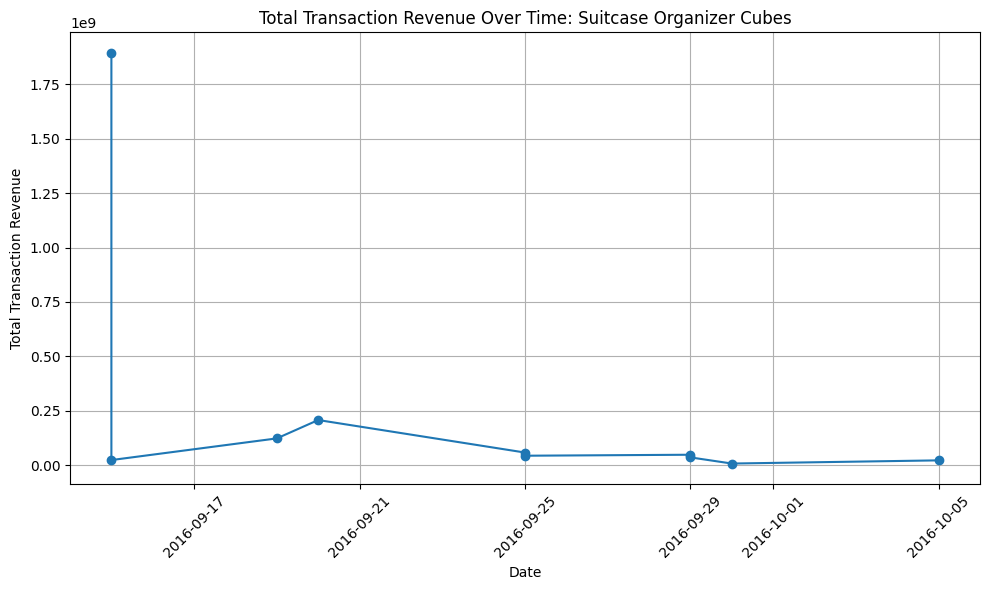

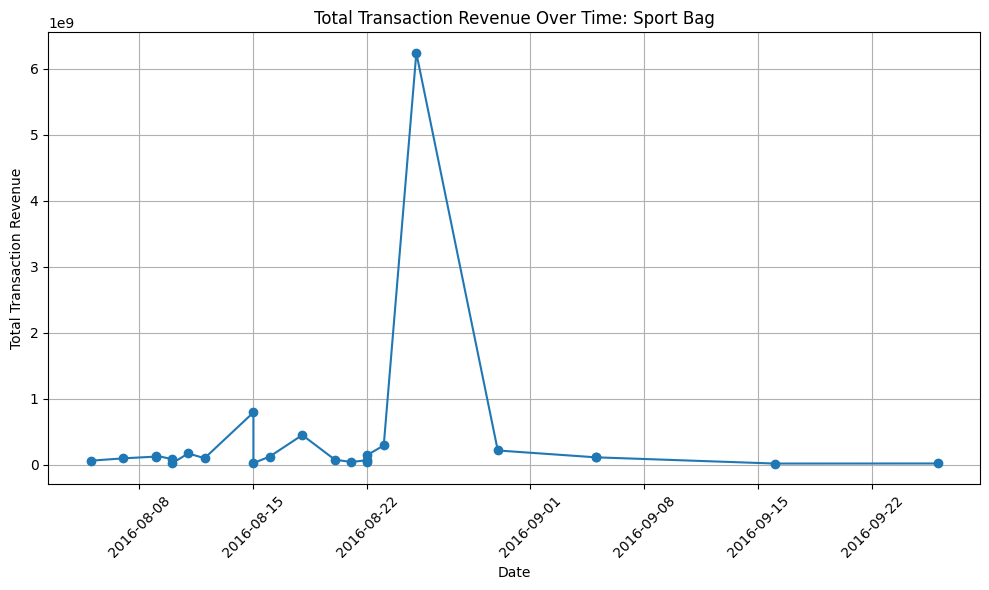

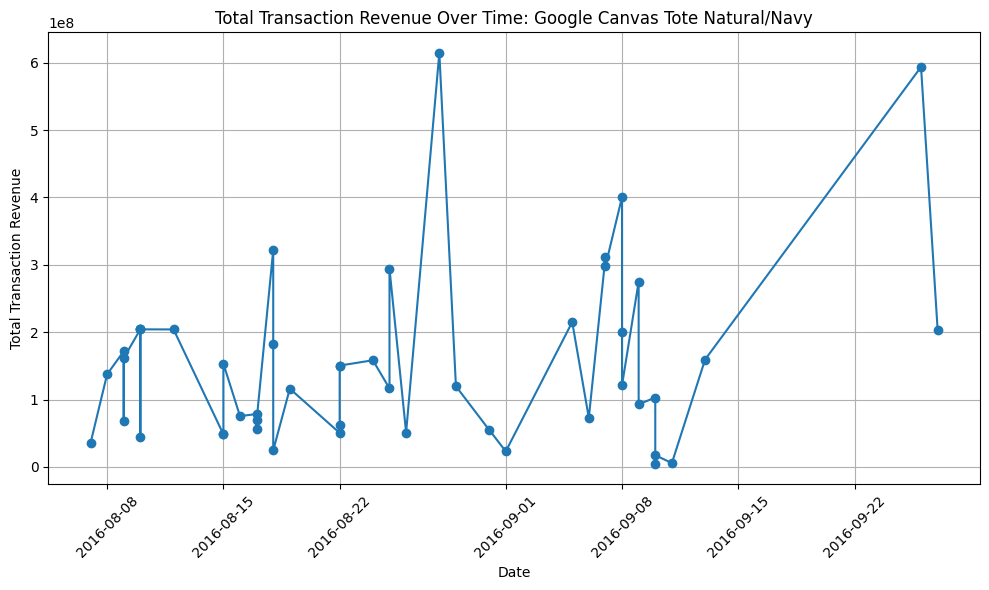

In [ ]:
topAnomalyProducts = anomalies['v2ProductName'].head(5).tolist()

for product in topAnomalyProducts:
    product_df = anomalies[anomalies['v2ProductName'] == product]
    
    product_df = product_df.sort_values('date')
    
    plt.figure(figsize=(10, 6))
    plt.plot(product_df['date'], product_df['totalTransactionRevenue'], marker='o')
    plt.title(f'Total Transaction Revenue Over Time: {product}')
    plt.xlabel('Date')
    plt.ylabel('Total Transaction Revenue')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

> From the graph, it's clear that these top 5 products show anomalies in their total product revenue. For example, the Google Pet Feeding and Sport Bag products were initially stable, but then experienced a significant spike in the middle of the graph, followed by a sudden drop. On the other hand, the 1 oz Hand Sanitizer and Suitcase Organizer Cubes started with high values but dropped sharply without any gradual change. The Google Canvas Tote Natural/Navy also showed frequent sharp fluctuations in both directions. Based on these patterns, it can be concluded that these products are relatively unstable. This could be due to several factors, such as high demand but limited stock, causing quick sell-outs, or perhaps the high price, which could lead to significant spikes when there are promotions driving sudden demand.

> With this analysis of the underlying causes, a more consistent business strategy can be developed to stabilize sales and revenue. By addressing these fluctuations, the business can create a safer and more predictable revenue stream.

# Finding Most Profitable Locations

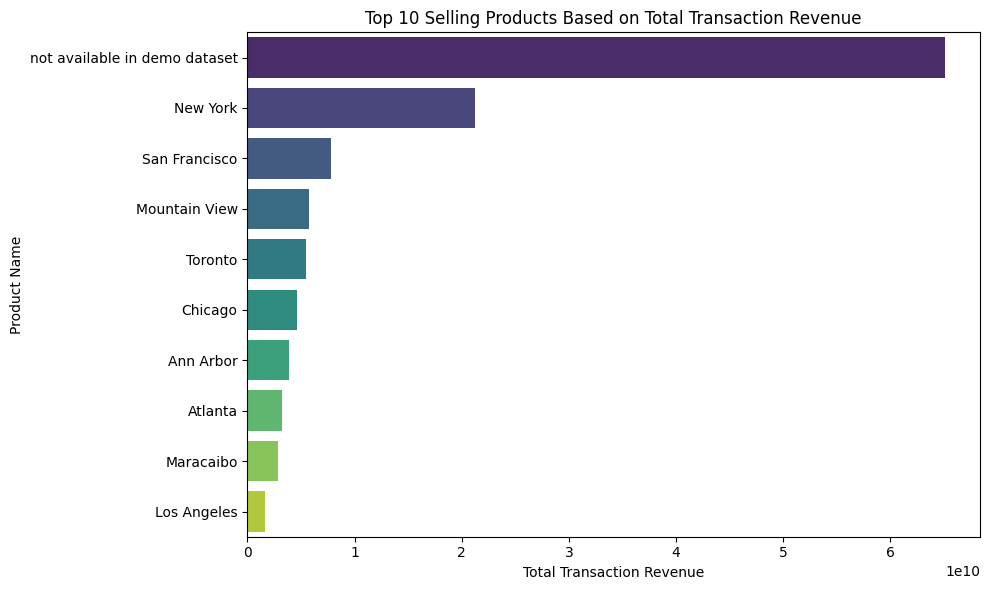

In [ ]:
city_revenue = df.dropna(subset=['totalTransactionRevenue'])
city_revenue = city_revenue.groupby('city')['totalTransactionRevenue'].sum().reset_index()

topCityRevenue = city_revenue.sort_values(by='totalTransactionRevenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=topCityRevenue.head(10), x='totalTransactionRevenue', y='city', palette='viridis', hue='city', legend=False)
plt.title('Top 10 Most Profitable Locations Based on Total Transaction Revenue')
plt.xlabel('Total Transaction Revenue')
plt.ylabel('Location Name')
plt.tight_layout()
plt.show()

> The top entry is labeled 'Not Available in Demo Dataset,' and its count is significantly high. Although it might be unnecessary to include it in the graph, it is important to highlight the lack of context in the dataset. Assuming the top location is New York, there is a notable gap compared to other locations, with the remaining locations showing relatively smaller, more typical gaps. This suggests that New York's high count could be attributed to factors such as its dense population, high consumer demand, or other contributing elements.

# Overall

> This result comes from a healthy discussion with the chatbot. The execution was simple, though there's definitely room for improvement. For instance, these three tasks were determined based on total product revenue, but other factors, as example, product quantity, could also be considered. A top-selling product might have high revenue simply because it's expensive, even though the quantity sold is the same or lower compared to others. However, given the dataset's limitations, I think the results are fairly enough.